In [1]:
%reload_ext autoreload 
%autoreload 2

In [2]:
import numpy as np 
from collections import OrderedDict

from qiskit_metal import designs, draw 
from qiskit_metal import MetalGUI, Dict, Headings

design = designs.DesignPlanar() 
gui = MetalGUI(design) 

design.overwrite_enabled=True

11:38PM 32s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 178 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



In [3]:
# necessary components 
from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL 
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander 
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors 
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder 
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond 
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled

Core of the chip 

In [4]:
design.variables.cpw_width = '10um' 
design.variables.cpw_gap = '6um' 
design._chips.main.size.size_x = '9mm' 
design._chips.main.size.size_y = '6.5mm' 

We need 4 transmons with 3 connection pads each and a chargeline. Let's explore the options for one transmon

In [5]:
TransmonPocketCL.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'make_CL': True,
 'cl_gap': '6um',
 'cl_width': '10um',
 'cl_length': '20um',
 'cl_ground_gap': '6um',
 'cl_pocket_edge': '0',
 'cl_off_center': '50um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 

Let's define a single option-dictionary to apply to all the transmons at the moment of creation. 

In [6]:
transmon_options = Dict(
    connection_pads=Dict( 
        a = Dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend='50um'), 
        b = Dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend='50um'), 
        c = Dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend='50um'), 
    ), 
    gds_cell_name='FakeJunction_01', 
    cl_off_center='-50um', 
    cl_pocket_edge='180', 
)

In [7]:
offset_tm = 69 # offset transmon slightly out of center line 

q1 = TransmonPocketCL(design, 'Q1', options = dict(
    pos_x='+2420um', pos_y=f'{offset_tm}um', **transmon_options)) 
q2 = TransmonPocketCL(design, 'Q2', options = dict(
    pos_x='0um', pos_y='-857.6um', orientation = '270', **transmon_options))
q3 = TransmonPocketCL(design, 'Q3', options = dict(
    pos_x='-2420um', pos_y=f'{offset_tm}um', orientation = '180', **transmon_options))
q4 = TransmonPocketCL(design, 'Q4', options = dict(
    pos_x='0um', pos_y='+857.6um', orientation = '90', **transmon_options))

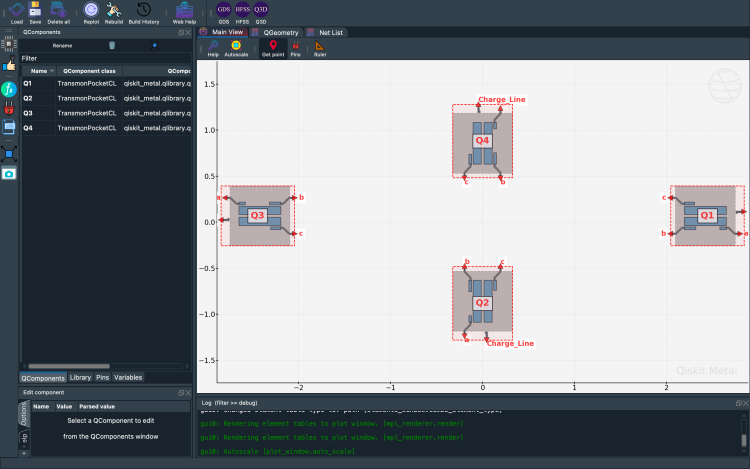

In [8]:
gui.rebuild()
gui.highlight_components(['Q1', 'Q2', 'Q3', 'Q4'])
gui.autoscale() 
gui.screenshot() 

Let's now connect the transmons with transmission lines. We want to have an "exact length" transmission line, so we will use the `RouteMeander` class. Let's first observe what the default options are. 

In [9]:
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

In [10]:
# override fillet and lead options 
fillet = '99.99um' 
cpw_options = Dict(
    lead=Dict(
        start_straight='100um', 
        end_straight='250um', 
    ), 
    fillet=fillet, 
)

In [11]:
# method to connect to pins with a CPWabs 

def connect( 
    cpw_name: str, 
    pin1_comp_name: str, 
    pin1_comp_pin: str, 
    pin2_comp_name: str, 
    pin2_comp_pin: str, 
    length: str, 
    asymmetry='0um', 
): 
    """ Connects two pins with a CPW. """ 
    myoptions = Dict( 
        pin_inputs=Dict(
            start_pin=Dict( 
                component=pin1_comp_name, 
                pin=pin1_comp_pin, 
            ), 
            end_pin=Dict(
                component=pin2_comp_name, 
                pin=pin2_comp_pin, 
            ),
        ), 
        total_length = length
    )
    myoptions.update(cpw_options) 
    myoptions.meander.asymmetry = asymmetry 
    return RouteMeander(design, cpw_name, myoptions)

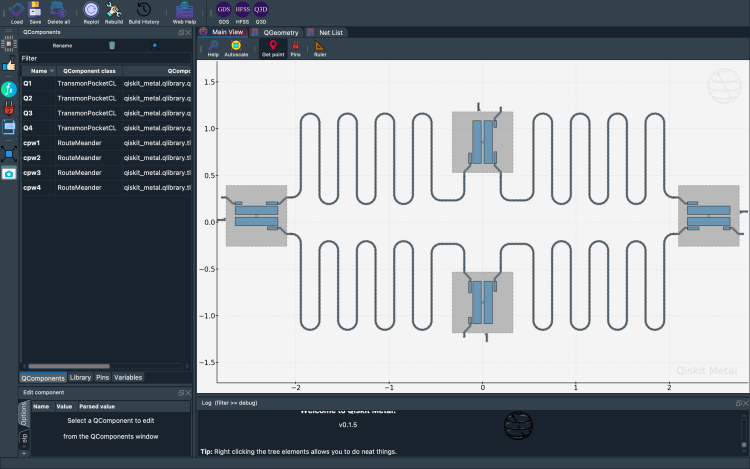

In [12]:
asym = 500
cpw1 = connect('cpw1', 'Q1', 'c', 'Q4', 'b', '9000um', f'-{asym-1.25*offset_tm}um')
cpw2 = connect('cpw2', 'Q3', 'b', 'Q4', 'c', '9000um', f'+{asym-1.25*offset_tm}um')
cpw3 = connect('cpw3', 'Q3', 'c', 'Q2', 'b', '9000um', f'-{asym+0.75*offset_tm}um')
cpw4 = connect('cpw4', 'Q1', 'b', 'Q2', 'c', '9000um', f'+{asym+0.75*offset_tm}um')

gui.rebuild()
gui.autoscale()
gui.screenshot()

Now let's connect the core elements to the launchpads 

First we setup the launchpad locations and orientations

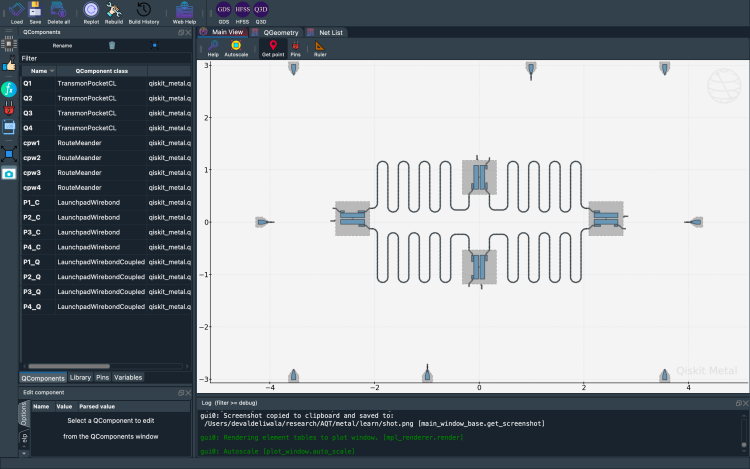

In [13]:
# V1 - Corners
p1_c = LaunchpadWirebond(design, 'P1_C', options = dict(pos_x='3545um', pos_y='2812um', orientation='270', lead_length='0um'))
p2_c = LaunchpadWirebond(design, 'P2_C', options = dict(pos_x='3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
p3_c = LaunchpadWirebond(design, 'P3_C', options = dict(pos_x='-3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
p4_c = LaunchpadWirebond(design, 'P4_C', options = dict(pos_x='-3545um', pos_y='2812um', orientation='270', lead_length='0um'))

# V2
p1_q = LaunchpadWirebondCoupled(design, 'P1_Q', options = dict(pos_x='4020um', pos_y='0', orientation='180', lead_length='30um'))
p2_q = LaunchpadWirebondCoupled(design, 'P2_Q', options = dict(pos_x='-990um', pos_y='-2812um', orientation='90', lead_length='30um'))
p3_q = LaunchpadWirebondCoupled(design, 'P3_Q', options = dict(pos_x='-4020um', pos_y='0', orientation='0', lead_length='30um'))
p4_q = LaunchpadWirebondCoupled(design, 'P4_Q', options = dict(pos_x='990um', pos_y='2812um', orientation='270', lead_length='30um'))

gui.rebuild()
gui.autoscale()
gui.screenshot()

Then we route. First the V2 Launchpads. 
We exchange Coupler Lines to Edges. 

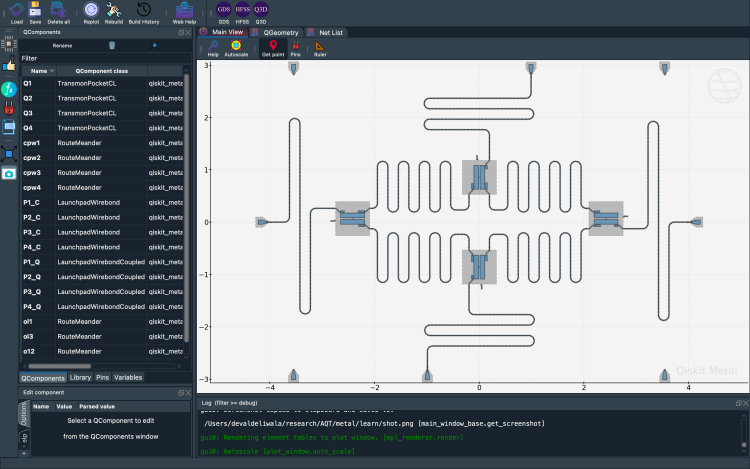

In [14]:
asym = 150 
cpw_options = Dict( 
    lead=Dict(
        start_straight='430um', 
        end_straight='0um', 
    ), 
    fillet=fillet, 
)

ol1 = connect('ol1', 'Q1', 'a', 'P1_Q', 'tie', '8.6mm', f'+{asym}um')
ol3 = connect('ol3', 'Q3', 'a', 'P3_Q', 'tie', '8.6mm', f'+{asym}um')

asym = 200
cpw_options = Dict(
    lead = Dict( 
        start_straight='535um', 
        end_straight='0um', 
    ), 
    fillet=fillet, 
)

o12 = connect('o12', 'Q2', 'a', 'P2_Q', 'tie', '8.6mm', f'+{asym}um') 
o14 = connect('o14', 'Q4', 'a', 'P4_Q', 'tie', '8.6mm', f'+{asym}um') 

gui.rebuild() 
gui.autoscale() 
gui.screenshot()

Finally we route the V1 Launchpads. Chargelines to corners. 
We create the transmission lines between the corner launch pads and the qubit charge lines. 

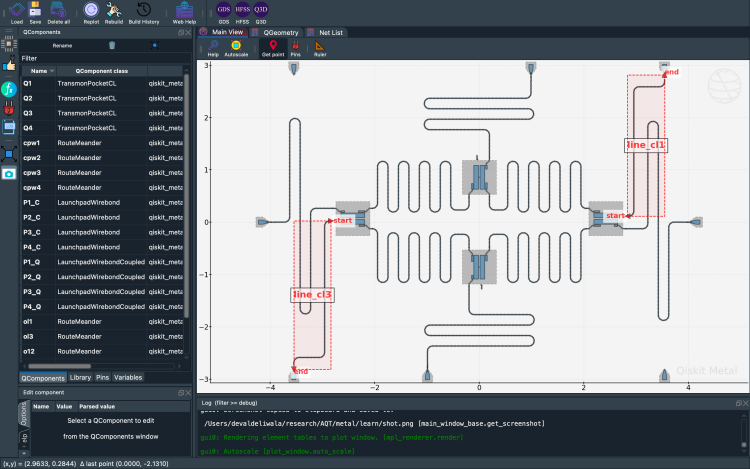

In [23]:
from collections import OrderedDict

jogsA_in = OrderedDict() 

jogsA_in[0] = ['L', '200um'] 

options_line_cl1 = Dict(
    pin_inputs=Dict(
        start_pin=Dict(
            component = 'Q1', 
            pin = 'Charge_Line', 
        ), 
        end_pin = Dict(
            component = 'P1_C', 
            pin = 'tie', 
        ), 
    ), 
    lead = Dict(
        start_straight = '120um', 
        end_straight = '225um', 
        start_jogged_extension = jogsA_in, 
    ), 
    fillet=fillet, 
)

cl1 = RouteAnchors(design, 'line_cl1', options_line_cl1) 

options_line_cl3 = {'pin_inputs':
            {'start_pin': {'component': 'Q3', 'pin': 'Charge_Line'},
             'end_pin': {'component': 'P3_C', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um', 'start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
cl3 = RouteAnchors(design, 'line_cl3', options_line_cl3)

gui.rebuild()
gui.highlight_components(['line_cl1', 'line_cl3'])
gui.autoscale()
gui.screenshot()

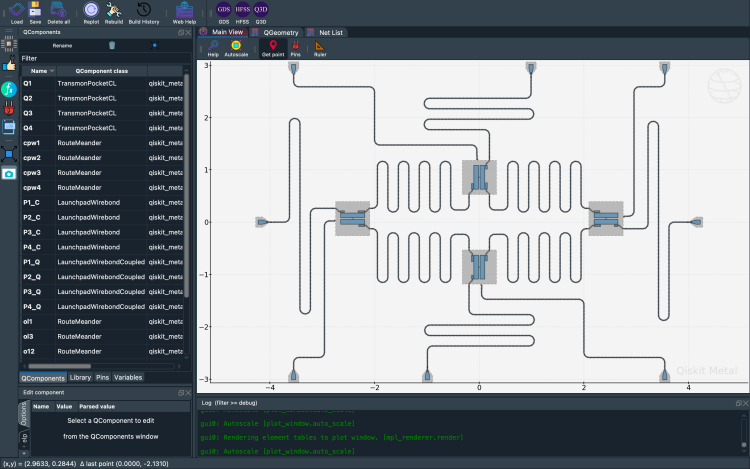

In [25]:
jogsB_in = OrderedDict()
jogsB_in[0] = ["L", '300um']

anchors2c = OrderedDict()
anchors2c[0] = np.array([2, -2.5])

options_line_cl2 = {'pin_inputs':
            {'start_pin': {'component': 'Q2', 'pin': 'Charge_Line'},
             'end_pin': {'component': 'P2_C', 'pin': 'tie'}},
            'lead': {'start_straight': '200um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors2c,
            'fillet': fillet
            }

cl2 = RouteAnchors(design, 'line_cl2', options_line_cl2)

anchors4c = OrderedDict()
anchors4c[0] = np.array([-2, 2.5])

options_line_cl4 = {'pin_inputs':
            {'start_pin': {'component': 'Q4', 'pin': 'Charge_Line'},
             'end_pin': {'component': 'P4_C', 'pin': 'tie'}},
            'lead': {'start_straight': '200um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors4c,
            'fillet': fillet
            }

cl4 = RouteAnchors(design, 'line_cl4', options_line_cl4)

gui.rebuild()
gui.autoscale()
gui.screenshot()

In [26]:
a_gds = design.renderers.gds 
a_gds.options

{'short_segments_to_not_fillet': 'True',
 'check_short_segments_by_scaling_fillet': '2.0',
 'gds_unit': 0.001,
 'ground_plane': 'True',
 'negative_mask': {'main': []},
 'fabricate': 'False',
 'corners': 'circular bend',
 'tolerance': '0.00001',
 'precision': '0.000000001',
 'width_LineString': '10um',
 'path_filename': '../resources/Fake_Junctions.GDS',
 'junction_pad_overlap': '5um',
 'max_points': '199',
 'cheese': {'datatype': '100',
  'shape': '0',
  'cheese_0_x': '25um',
  'cheese_0_y': '25um',
  'cheese_1_radius': '100um',
  'view_in_file': {'main': {1: True}},
  'delta_x': '100um',
  'delta_y': '100um',
  'edge_nocheese': '200um'},
 'no_cheese': {'datatype': '99',
  'buffer': '25um',
  'cap_style': '2',
  'join_style': '2',
  'view_in_file': {'main': {1: True}}},
 'bounding_box_scale_x': '1.2',
 'bounding_box_scale_y': '1.2'}

In [27]:
a_gds.options.no_cheese.buffer = '50um'

In [29]:
a_gds.options.path_filename = './pattern_files/Fake_Junctions.gds' 
a_gds.export_to_gds('4_chip_design.gds')

11:43PM 35s WARNING [_import_junction_gds_file]: Not able to find file:"./pattern_files/Fake_Junctions.gds".  Not used to replace junction. Checked directory:"/Users/devaldeliwala/research/AQT/metal/learn/pattern_files".


1

In [30]:
gui.main_window.close()

True